In [1]:
import awkward as ak
import pandas as pd
import uproot
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def CreateTreeAndGetEvents(path, treeName):
    file = uproot.open(path)
    tree = file.get(treeName)
    tree.show()
    events = tree.arrays(library = "ak")
    return events

mcPath = "/home/mutu/Desktop/RTE/build/filteredMC.root"
#dataPath = "/home/mutu/Desktop/Fermilab-simulationStided/BeamClusterAnalysis/dowloandedFromgpvm/processed/yeniIndirilen/processingData_EBV2-BeamClusterTrees-R56*/R56.root"
treeName = "Event"

#events   = CreateTreeAndGetEvents(dataPath, treeName)
mcEvents = CreateTreeAndGetEvents(mcPath, treeName)

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
runNumber            | int32_t                  | AsDtype('>i4')
subrunNumber         | int32_t                  | AsDtype('>i4')
partFileNumber       | int32_t                  | AsDtype('>i4')
runType              | int32_t                  | AsDtype('>i4')
eventNumber          | int32_t                  | AsDtype('>i4')
PrimaryTriggerWord   | int32_t                  | AsDtype('>i4')
GroupedTriggerTime   | std::vector<uint64_t>    | AsJagged(AsDtype('>u8'), he...
GroupedTriggerWord   | std::vector<uint32_t>    | AsJagged(AsDtype('>u4'), he...
trigword             | int32_t                  | AsDtype('>i4')
Extended             | int32_t                  | AsDtype('>i4')
HasTank              | int32_t                  | AsDtype('>i4')
HasMRD               | int32_t                  | AsDtype('>i4')
HasLAPPD             | int

In [24]:
mask = mcEvents["trueCC"] == 1
mcEvents["trueMuonEnergy"][mask]

<Array [328, 532, 1.41e+03, 255, ..., 300, 734, 246] type='111339 * float64'>

In [5]:
rows = []  # tablo satırlarını tutacak liste

# başlangıç maskesi: tüm eventler True (hiç cut yok)
current_mask = ak.ones_like(mcEvents["trueCC"], dtype=bool)

# -------- No cut --------

# CC ve NC eventleri ayır
cc_mask = (mcEvents["trueCC"] == 1) & current_mask
nc_mask = (mcEvents["trueCC"] == 0) & current_mask

# enerji değerlerini al
cc_energy = mcEvents["trueMuonEnergy"][cc_mask]
nc_energy = mcEvents["trueMuonEnergy"][nc_mask]

# ortalama enerjileri hesapla
mean_cc = ak.mean(cc_energy)
mean_nc = ak.mean(nc_energy)

# None ise -1 yap, değilse float'a çevir
mean_cc = float(mean_cc) if mean_cc is not None else -1
mean_nc = float(mean_nc) if mean_nc is not None else -1

# ilk satırı ekle (cut yok)
rows.append({
    "Cut": "No cut",
    "CC Event": int(ak.sum(cc_mask)),  # CC event sayısı
    "NC Event": int(ak.sum(nc_mask)),  # NC event sayısı
    "True mean muon energy (CC)": mean_cc,         # CC ortalama enerji
    "True mean muon energy (NC)": mean_nc          # NC ortalama enerji
})

# -------- cumulative cuts --------
cuts = [
    #"passBeamOK",
    #"passBRFWindow",
    #"passPPSMissing",
    #"passRequireLAPPD",
    "passPairedEvent",
    "passPromptPMTCluster",
    "passHighQualityPMTCluster",
    "passTankMRDCoinc",
    "passMRDRecoTrack",
    "passMuonTopology"
    #"passMRDTrackReconstructed",

    #"passMuonTopology",
    #"passNoVeto",
]

for cut in cuts:
    # mevcut maskeye yeni cut ekle (kümülatif)
    current_mask = current_mask & (mcEvents[cut] == 1)

    # cut sonrası CC ve NC ayır
    cc_mask = (mcEvents["trueCC"] == 1) & current_mask
    nc_mask = (mcEvents["trueCC"] == 0) & current_mask

    # enerji değerlerini al
    cc_energy = mcEvents["trueMuonEnergy"][cc_mask]
    nc_energy = mcEvents["trueMuonEnergy"][nc_mask]

    # ortalama enerji hesapla
    mean_cc = ak.mean(cc_energy)
    mean_nc = ak.mean(nc_energy)

    # None kontrolü + float dönüşümü
    mean_cc = float(mean_cc) if mean_cc is not None else -1
    mean_nc = float(mean_nc) if mean_nc is not None else -1

    # tabloya yeni satır ekle
    rows.append({
        "Cut": cut,
        "CC Event": int(ak.sum(cc_mask)),
        "NC Event": int(ak.sum(nc_mask)),
        "True mean muon energy (CC)": mean_cc,
        "True mean muon energy (NC)": mean_nc
    })

# listeyi pandas DataFrame'e çevir
cutflowTable = pd.DataFrame(rows)

# toplam event sayısı
cutflowTable["Total"] = cutflowTable["CC Event"] + cutflowTable["NC Event"]

# CC oranı (%)
cutflowTable["CC Ratio [%]"] = 100 * cutflowTable["CC Event"] / cutflowTable["Total"]

# sütun sırasını düzenle (energy en sağda)
cutflowTable = cutflowTable[
    ["Cut", "CC Event", "NC Event", "Total", "CC Ratio [%]",
     "True mean muon energy (CC)", "True mean muon energy (NC)"]
]

# tabloyu göster
cutflowTable

,Cut,CC Event,NC Event,Total,CC Ratio [%],True mean muon energy (CC),True mean muon energy (NC)
0,No cut,111339,48661,160000,69.586875,660.539967,-9996.645325
1,passPairedEvent,111339,48661,160000,69.586875,660.539967,-9996.645325
2,passPromptPMTCluster,94530,28388,122918,76.904928,664.665713,-9996.467344
3,passHighQualityPMTCluster,37757,8890,46647,80.941968,703.758419,-9994.404007
4,passTankMRDCoinc,6935,275,7210,96.185853,1347.540799,-9962.578824
5,passMRDRecoTrack,5593,88,5681,98.450977,1422.342532,-9885.183825
6,passMuonTopology,3303,24,3327,99.278629,1573.864042,-9581.674026


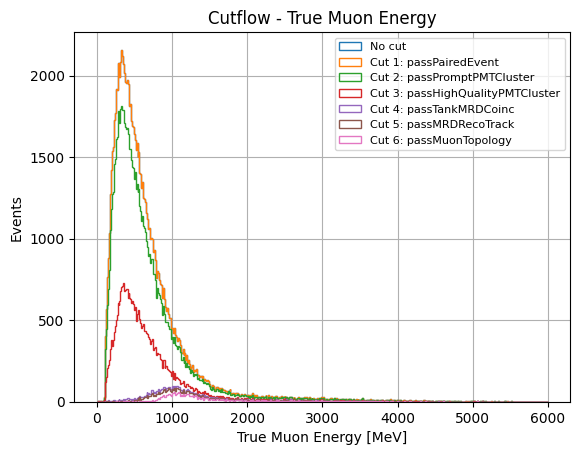

In [6]:
energy_branch = "trueMuonEnergy"

plt.figure()

mask = ak.ones_like(mcEvents["trueCC"], dtype=bool)

# No cut
plt.hist(ak.to_numpy(mcEvents["trueMuonEnergy"][mask]),
         bins=500, range=(0,6000),
         histtype="step",
         label="No cut")

for i, cut in enumerate(cuts, start=1):
    
    mask = mask & (mcEvents[cut] == 1)
    energy_values = ak.to_numpy(mcEvents["trueMuonEnergy"][mask])
    
    label = f"Cut {i}: {cut}"
    
    plt.hist(energy_values,
             bins=500, range=(0,6000),
             histtype="step",
             label=label)

plt.xlabel("True Muon Energy [MeV]")
plt.ylabel("Events")
plt.title("Cutflow - True Muon Energy")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

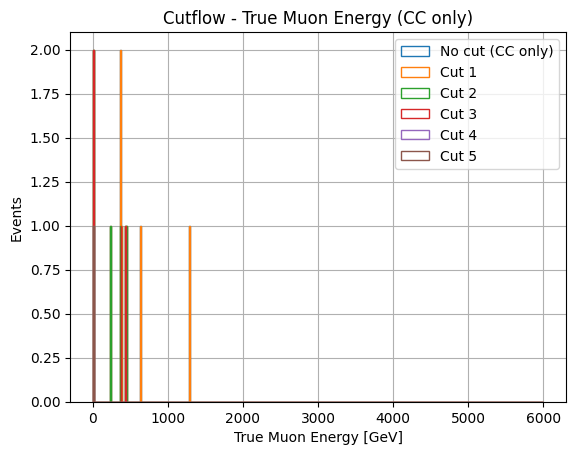

In [14]:
plt.figure()

energy_branch = "trueMuonEnergy"

# SADECE CC seçimi
mask = (mcEvents["trueCC"] == 0)

# No cut (ama zaten sadece CC)
plt.hist(ak.to_numpy(mcEvents[energy_branch][mask]),
         bins=500, range=(0,6000),
         histtype="step",
         label="No cut (CC only)")

# Cutları uygula
for i, cut in enumerate(cuts, start=1):
    
    mask = mask & (mcEvents[cut] == 1)

    energy_values = ak.to_numpy(mcEvents[energy_branch][mask])
    
    label = f"Cut {i}"
    
    plt.hist(energy_values,
             bins=500, range=(0,6000),
             histtype="step",
             label=label)

plt.xlabel("True Muon Energy [GeV]")
plt.ylabel("Events")
#plt.yscale("log")
plt.title("Cutflow - True Muon Energy (CC only)")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
print(len(mcEvents[(mcEvents["trueCC"] == 0)]))
print(len(mcEvents[(mcEvents["trueCC"] == 0) & (mcEvents["passMRDTrackReconstructed"] == 1)]))

12139
742


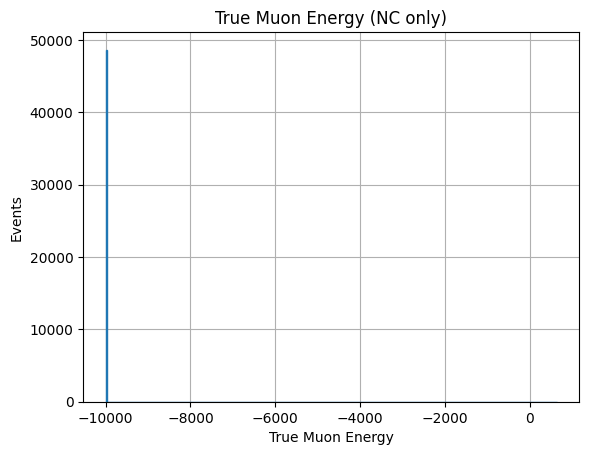

In [13]:
#NC durumunda zaten muon yok -999 geliyor fakat histo pozitif yapiyor onu

energy_branch = "trueMuonEnergy"

# sadece NC seçimi (senin dediğin gibi trueNC == 1)
mask = (mcEvents["trueNC"] == 1)

energy_values = ak.to_numpy(mcEvents[energy_branch][mask])

plt.figure()
plt.hist(energy_values,
         bins=500,
         #range=(0, 6000),
         histtype="step")

plt.xlabel("True Muon Energy")
plt.ylabel("Events")
plt.title("True Muon Energy (NC only)")
plt.grid(True)

plt.show()

In [11]:
energy_values

array([-9999.        , -9999.        , -9999.        , ...,
       -9999.        ,   382.66885376, -9999.        ], shape=(12139,))